In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

from collections import Counter, defaultdict
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu
from matplotlib.patches import Patch

In [2]:
PT_DIR = Path(
    "logs/hidden_states/math/(specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"
)
PT_DIR_ADD = Path(
    "logs/hidden_states/math/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"
)
JSONL_PATH = Path(
    "logs/math/sharded-at0-ut0/(specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"
)
JSONL_PATH_ADD = Path(
    "logs/math/sharded-at0-ut0/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"
)

PT_SOURCES    = [PT_DIR, PT_DIR_ADD]
JSONL_SOURCES = [JSONL_PATH, JSONL_PATH_ADD]
LAYERS        = [12, 16, 20, 24, 28]
FOCUS_LAYER_IDX = LAYERS.index(24)   # index used throughout

ALL_TYPES = ["answer_attempt", "clarification", "refusal",
             "hedging", "interrogation", "discussion", "missing"]

# Canonical rt label normalisation
# (data uses "hedge"/"refuse"; normalise to match ALL_TYPES)
RT_NORM = {"hedge": "hedging", "refuse": "refusal"}

TYPE_COLORS = {
    "answer_attempt": "#2196F3",
    "clarification" : "#4CAF50",
    "refusal"       : "#F44336",
    "hedging"       : "#FF9800",
    "interrogation" : "#9C27B0",
    "discussion"    : "#00BCD4",
    "missing"       : "#9E9E9E",
}

In [3]:
def turn_sort_key(label: str):
    if not label.startswith("turn_"):
        return (1, label)
    try:
        return (0, int(label.split("_", 1)[1]))
    except ValueError:
        return (0, label)

def turn_index(label: str) -> int:
    return int(label.split("_", 1)[1])

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-9 or nb < 1e-9:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

def styled_ax(ax):
    """Apply dark-theme styling to a matplotlib axis."""
    ax.set_facecolor("#16161e")
    ax.tick_params(colors="#888899")
    for sp in ax.spines.values():
        sp.set_edgecolor("#2a2a3a")

In [4]:
# ── Step 1: Load .pt hidden-state files ──────────────────────────────────────
# Pipeline recap:
#   prefill([sys + Shard0])                     → hs "goal"
#   prefill([sys + Shard0 + Ans0 + Shard1])     → hs "turn_1"
#   prefill([... + Ans1 + Shard2])              → hs "turn_2"  ...
# So hs["turn_N"] = model state BEFORE generating Answer_N.

conv_records = {}
seen, stats = set(), defaultdict(int)

for pt_dir in PT_SOURCES:
    pt_files = sorted(pt_dir.glob("*.pt"))
    print(f"  {pt_dir.name}: {len(pt_files)} files")
    for pt_file in pt_files:
        conv_id = pt_file.stem
        if conv_id in seen:
            stats["duplicate"] += 1; continue
        seen.add(conv_id)

        data        = torch.load(pt_file, map_location="cpu", weights_only=False)
        hs_list     = data.get("hidden_states", [])
        hs_by_label = {e["label"]: e["hidden_states"] for e in hs_list}

        if "goal" not in hs_by_label:
            stats["no_goal"] += 1; continue

        turn_labels = sorted(
            [k for k in hs_by_label if k.startswith("turn_")],
            key=turn_sort_key,
        )
        if len(turn_labels) < 3:
            stats["too_few_turns"] += 1; continue

        conv_records[conv_id] = {
            "goal_hs" : [hs_by_label["goal"][i].numpy() for i in range(len(LAYERS))],
            "turns_hs": {tl: [hs_by_label[tl][i].numpy() for i in range(len(LAYERS))]
                         for tl in turn_labels},
            "max_turn": max(turn_index(tl) for tl in turn_labels),
        }

print(f"\nLoaded: {len(conv_records)} conversations")
for k, v in stats.items():
    if v: print(f"  Skipped ({k}): {v}")

  (specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct: 103 files
  (add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct: 241 files

Loaded: 320 conversations
  Skipped (too_few_turns): 24


In [5]:
# ── Step 2: Load JSONL → score_map + turn_rt_map ─────────────────────────────
# score_map   : conv_id → 0/1
# turn_rt_map : conv_id → {turn_idx: response_type}
#
# Alignment:
#   user_turn_idx increments on each "user" entry.
#   The "system-verification" log immediately follows the assistant turn,
#   so turn_rt_map[conv_id][N] = type of Answer_N
#   which pairs correctly with hs["turn_N"] (pre-Answer_N state).

score_map   = {}
turn_rt_map = {}

for jsonl_path in JSONL_SOURCES:
    loaded = 0
    with open(jsonl_path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            rec     = json.loads(line)
            conv_id = rec.get("conv_id")
            if conv_id is None: continue

            score = rec.get("score")
            score_map[conv_id] = int(float(score)) if score is not None else 0

            trace, turn_rt, user_turn_idx = rec.get("trace", []), {}, 0
            for entry in trace:
                role = entry.get("role", "")
                if role == "user":
                    user_turn_idx += 1
                elif role == "log":
                    content = entry.get("content", {})
                    if isinstance(content, dict) and content.get("type") == "system-verification":
                        rt = content.get("response", {}).get("response_type", "missing")
                        rt = RT_NORM.get(rt, rt)   # normalise hedge/refuse
                        turn_rt[user_turn_idx] = rt

            turn_rt_map[conv_id] = turn_rt
            loaded += 1

    print(f"  {jsonl_path.name}: {loaded} records")

n_c = sum(v == 1 for v in score_map.values())
n_i = sum(v == 0 for v in score_map.values())
print(f"\nTotal: {len(score_map)}  (correct={n_c}, incorrect={n_i})")
print("RT distribution:", Counter(rt for d in turn_rt_map.values() for rt in d.values()))

  (specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl: 103 records
  (add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl: 241 records

Total: 344  (correct=168, incorrect=176)
RT distribution: Counter({'answer_attempt': 738, 'discussion': 589, 'clarification': 290, 'interrogation': 38, 'hedging': 24, 'refusal': 20, 'missing': 8})


In [6]:
# ── Step 3 (PCA part 1): Build response-type mean vectors ────────────────────
# Mirrors Assistant Axis paper §2.1.2:
#   For each rt, collect all turn hidden states where that type occurred
#   → take mean → one "role vector" per type per layer.
# Note: we use hs["turn_N"] which is pre-Answer_N — correctly captures
# the model state that *leads to* each response strategy.

rt_accum = {li: defaultdict(list) for li in range(len(LAYERS))}

for conv_id, rec in conv_records.items():
    turn_rt  = turn_rt_map.get(conv_id, {})
    for t_label, hs_per_layer in rec["turns_hs"].items():
        t_idx = turn_index(t_label)
        rt    = turn_rt.get(t_idx, "missing")
        for li, hs in enumerate(hs_per_layer):
            rt_accum[li][rt].append(hs)

rt_vectors = {
    li: {rt: np.mean(vecs, axis=0) for rt, vecs in rt_accum[li].items()}
    for li in range(len(LAYERS))
}

print("Sample counts per type (layer 20):")
print({rt: len(v) for rt, v in rt_accum[FOCUS_LAYER_IDX].items()})

Sample counts per type (layer 20):
{'clarification': 280, 'interrogation': 38, 'discussion': 542, 'answer_attempt': 436, 'refusal': 19, 'hedging': 24, 'missing': 8}


Total samples: 1347
  answer_attempt: 436
  clarification: 280
  refusal: 19
  hedging: 24
  interrogation: 38
  discussion: 542
  missing: 8

Variance explained (pre-averaging PCA, layer 24):
  PC1: 13.30%
  PC2: 8.82%
  PC3: 5.84%
  PC4: 5.06%
  PC5: 4.32%

Silhouette score (PC1+PC2, n=1347): -0.0847
  (-1 → opposite side, 0 → heavy overlap, +1 → clean separation)


/tmp/ipykernel_3748418/1307244414.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


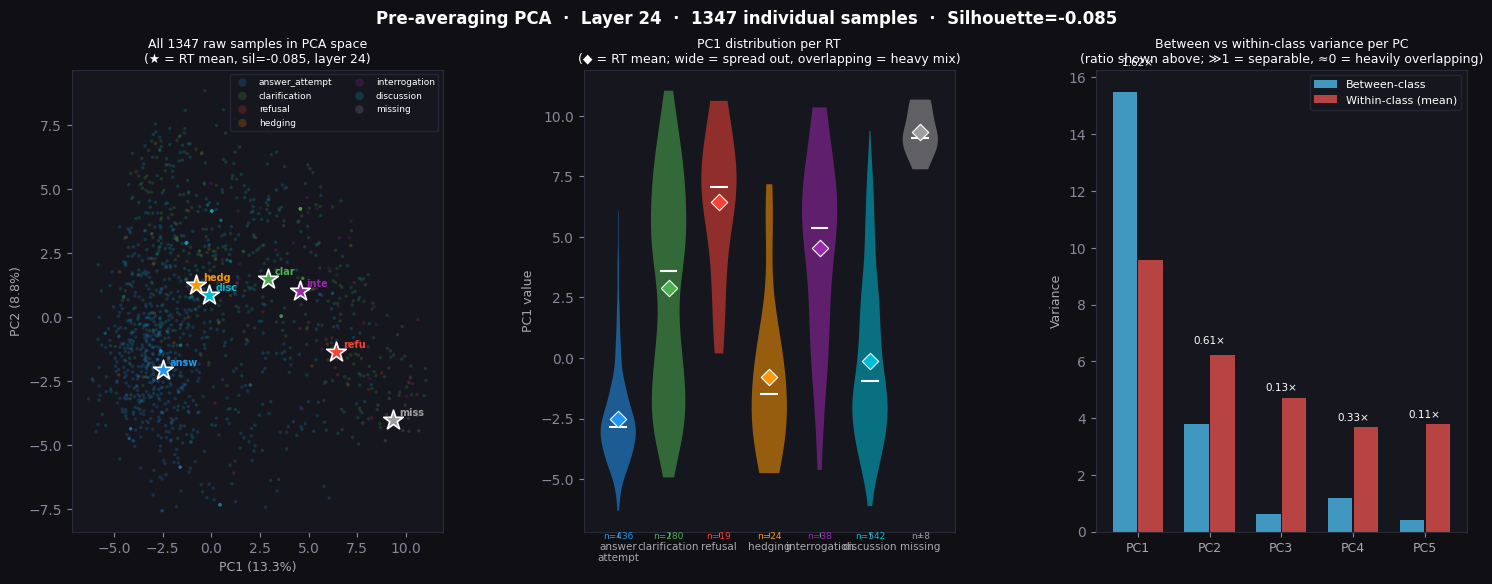

In [8]:
# ── Pre-averaging PCA: all individual samples ────────────────────────────────
# Before any averaging, check whether individual hidden states are separable
# or heavily overlapping in PCA space.
#
# Key question: does averaging HIDE meaningful structure, or does the raw
# hidden-state cloud already show clear RT separation?
#
# Method:
#   1. Stack ALL individual hidden states (no subsample limit)
#   2. Fit PCA on the full set (subtract global mean first)
#   3. Panel A: scatter in PC1/PC2, all points + RT means as stars
#   4. Panel B: PC1 violin per RT (shows distributional overlap)
#   5. Panel C: between- vs within-class variance per PC (quantifies separability)
#   6. Silhouette score as a single-number overlap metric

from sklearn.metrics import silhouette_score

TARGET_LI = FOCUS_LAYER_IDX  # layer 24
rng2 = np.random.default_rng(7)

# ── 1. Stack ALL samples ──────────────────────────────────────────────────────
present_rts = [rt for rt in ALL_TYPES
               if rt in rt_accum[TARGET_LI] and len(rt_accum[TARGET_LI][rt]) > 0]

big_X_list, big_y_list = [], []
for rt in present_rts:
    xs = rt_accum[TARGET_LI][rt]
    big_X_list.extend(xs)
    big_y_list.extend([rt] * len(xs))

big_X = np.stack(big_X_list)   # (N_total, hidden_dim)
big_y = np.array(big_y_list)   # (N_total,)

print(f"Total samples: {len(big_X)}")
for rt in present_rts:
    print(f"  {rt}: {(big_y == rt).sum()}")

# ── 2. PCA on full dataset ────────────────────────────────────────────────────
global_mean_full = big_X.mean(axis=0)
pca_full = PCA(n_components=5)
Z_full = pca_full.fit_transform(big_X - global_mean_full)

print(f"\nVariance explained (pre-averaging PCA, layer {LAYERS[TARGET_LI]}):")
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.2f}%")

# ── 3. Project RT means onto the same PCA space ───────────────────────────────
rt_means_proj = {}
for rt in present_rts:
    mu = rt_vectors[TARGET_LI][rt]
    rt_means_proj[rt] = pca_full.transform((mu - global_mean_full).reshape(1, -1))[0]

# ── 4. Silhouette score (subset for speed; O(n^2)) ───────────────────────────
N_SIL = 2000
if len(big_X) > N_SIL:
    idx_sil = rng2.choice(len(big_X), N_SIL, replace=False)
    sil = silhouette_score(Z_full[idx_sil, :2], big_y[idx_sil])
    print(f"\nSilhouette score (PC1+PC2, n={N_SIL}): {sil:.4f}")
else:
    sil = silhouette_score(Z_full[:, :2], big_y)
    print(f"\nSilhouette score (PC1+PC2, n={len(big_X)}): {sil:.4f}")
print("  (-1 → opposite side, 0 → heavy overlap, +1 → clean separation)")

# ── 5. Figure ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor("#0f0f14")
gs_pre = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Panel A: PC1 vs PC2 scatter — all individual points + RT mean stars
ax = fig.add_subplot(gs_pre[0]); styled_ax(ax)
for rt in present_rts:
    mask = big_y == rt
    ax.scatter(Z_full[mask, 0], Z_full[mask, 1],
               s=6, alpha=0.20, color=TYPE_COLORS.get(rt, "#aaa"),
               edgecolors="none", label=rt)
for rt in present_rts:
    p = rt_means_proj[rt]
    ax.scatter(p[0], p[1], s=220, color=TYPE_COLORS.get(rt, "#aaa"),
               edgecolors="white", linewidths=1.2, zorder=6, marker="*")
    ax.annotate(rt[:4], (p[0], p[1]), xytext=(5, 3),
                textcoords="offset points", fontsize=7,
                color=TYPE_COLORS.get(rt, "#aaa"), fontweight="bold")
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)", color="#aaaaaa", fontsize=9)
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)", color="#aaaaaa", fontsize=9)
ax.set_title(f"All {len(big_X)} raw samples in PCA space\n"
             f"(★ = RT mean, sil={sil:.3f}, layer {LAYERS[TARGET_LI]})",
             color="white", fontsize=9, pad=5)
ax.legend(facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white",
          fontsize=6.5, ncol=2, markerscale=2.5)

# Panel B: PC1 violin per RT (overlap along principal axis)
ax = fig.add_subplot(gs_pre[1]); styled_ax(ax)
pc1_per_rt = [Z_full[big_y == rt, 0] for rt in present_rts]
vp = ax.violinplot(pc1_per_rt, positions=range(len(present_rts)),
                   widths=0.7, showmedians=True, showextrema=False)
for body, rt in zip(vp["bodies"], present_rts):
    body.set_facecolor(TYPE_COLORS.get(rt, "#aaa")); body.set_alpha(0.55)
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(1.5)
for i, rt in enumerate(present_rts):
    ax.scatter(i, rt_means_proj[rt][0], s=70, color=TYPE_COLORS.get(rt, "#aaa"),
               edgecolors="white", linewidths=0.8, zorder=5, marker="D")
    n = (big_y == rt).sum()
    ax.text(i, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else -1,
            f"n={n}", ha="center", fontsize=6.5, color=TYPE_COLORS.get(rt, "#aaa"), va="top")
ax.set_xticks(range(len(present_rts)))
ax.set_xticklabels([rt.replace("_", "\n") for rt in present_rts], fontsize=7.5, color="#aaaaaa")
ax.set_ylabel("PC1 value", color="#aaaaaa", fontsize=9)
ax.set_title("PC1 distribution per RT\n(◆ = RT mean; wide = spread out, overlapping = heavy mix)",
             color="white", fontsize=9, pad=5)

# Panel C: between-class vs within-class variance per PC
ax = fig.add_subplot(gs_pre[2]); styled_ax(ax)
n_pc_show = min(5, pca_full.n_components_)
bc_vars, wc_vars = [], []
for pc_i in range(n_pc_show):
    class_means = [Z_full[big_y == rt, pc_i].mean()
                   for rt in present_rts if (big_y == rt).sum() > 0]
    bc_vars.append(np.var(class_means))
    wc_vars.append(np.mean([Z_full[big_y == rt, pc_i].var()
                             for rt in present_rts if (big_y == rt).sum() > 0]))

x_pc = np.arange(n_pc_show)
ax.bar(x_pc - 0.18, bc_vars, 0.34, color="#4fc3f7", alpha=0.75, label="Between-class")
ax.bar(x_pc + 0.18, wc_vars, 0.34, color="#ef5350", alpha=0.75, label="Within-class (mean)")
for i in range(n_pc_show):
    ratio = bc_vars[i] / wc_vars[i] if wc_vars[i] > 1e-12 else 0
    ax.text(i, max(bc_vars[i], wc_vars[i]) * 1.06, f"{ratio:.2f}×",
            ha="center", fontsize=7.5, color="white")
ax.set_xticks(x_pc)
ax.set_xticklabels([f"PC{i+1}" for i in range(n_pc_show)], color="#aaaaaa", fontsize=9)
ax.set_ylabel("Variance", color="#aaaaaa", fontsize=9)
ax.set_title("Between vs within-class variance per PC\n"
             "(ratio shown above; ≫1 = separable, ≈0 = heavily overlapping)",
             color="white", fontsize=9, pad=5)
ax.legend(facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white", fontsize=8)

fig.suptitle(
    f"Pre-averaging PCA  ·  Layer {LAYERS[TARGET_LI]}  ·  {len(big_X)} individual samples  "
    f"·  Silhouette={sil:.3f}",
    color="white", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [17]:
# ── Step 4: Build curvature records ──────────────────────────────────────────
# For each conv, at focus layer:
#   delta_t = hs[t] - hs[t-1]
#   curvature_t = cos(delta_t, delta_{t-1})   ← defined from turn index 3+
#
# Each record: (conv_id, turn_idx, rt, score, curvature, is_transition)
# rt alignment: turn_rt[N] = type of Answer_N, paired with hs["turn_N"]
# which is the pre-Answer_N state → causal direction correct.

records = []

for conv_id, rec in conv_records.items():
    score   = score_map.get(conv_id)
    if score is None: continue
    turn_rt  = turn_rt_map.get(conv_id, {})
    turns_hs = rec["turns_hs"]

    turn_labels = sorted(
        [k for k in turns_hs if k.startswith("turn_")],
        key=lambda l: int(l.split("_")[1])
    )
    if len(turn_labels) < 3: continue

    idxs   = [int(l.split("_")[1]) for l in turn_labels]
    hs_seq = [turns_hs[l][FOCUS_LAYER_IDX] for l in turn_labels]
    deltas = [hs_seq[i] - hs_seq[i-1] for i in range(1, len(hs_seq))]

    for i in range(1, len(deltas)):
        t_idx   = idxs[i + 1]
        rt      = turn_rt.get(t_idx, "missing")
        rt_prev = turn_rt.get(idxs[i], "missing")
        records.append({
            "conv_id"       : conv_id,
            "turn"          : t_idx,
            "score"         : score,
            "rt"            : rt,
            "rt_prev"       : rt_prev,
            "is_transition" : rt != rt_prev,
            "curvature"     : cosine(deltas[i], deltas[i-1]),
            "max_turn"      : rec["max_turn"],
        })

print(f"Built {len(records)} (conv, turn) curvature records")
print("RT distribution in records:", Counter(r["rt"] for r in records))

Built 707 (conv, turn) curvature records
RT distribution in records: Counter({'answer_attempt': 354, 'discussion': 244, 'clarification': 93, 'hedging': 10, 'interrogation': 6})


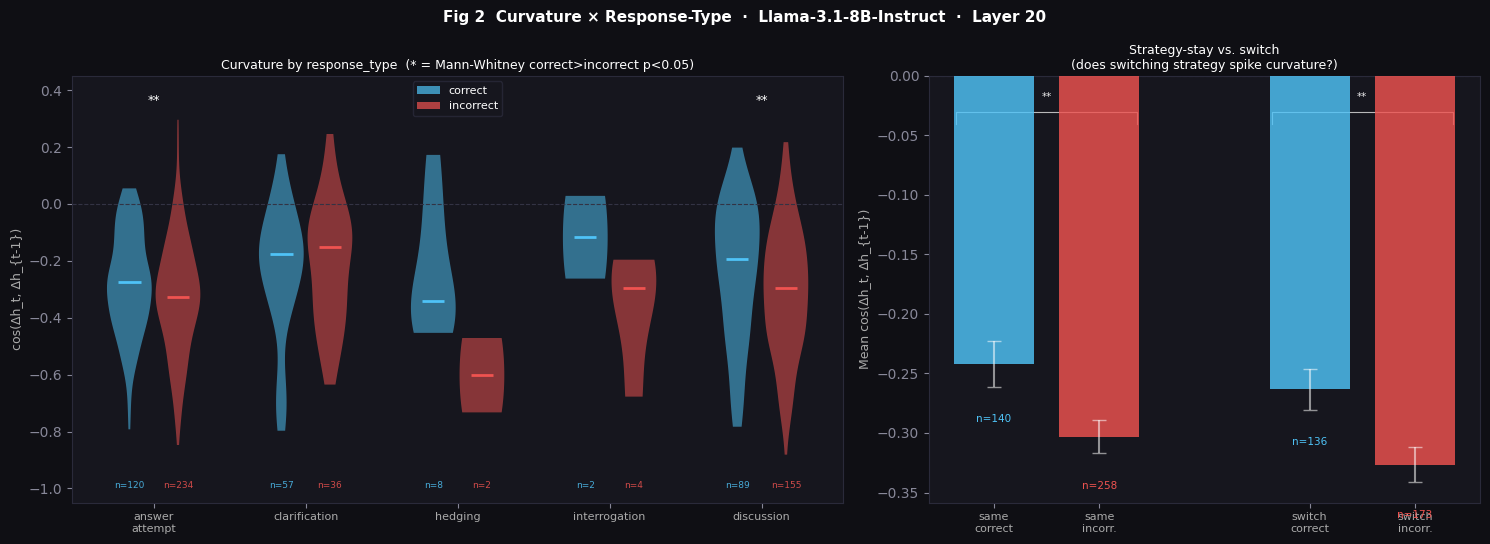

In [18]:
# ── Fig 2: Curvature × Response-Type ─────────────────────────────────────────
# Left:  violin — curvature distribution per rt, correct vs incorrect
#        + Mann-Whitney U significance stars
# Right: bar — curvature at strategy-stay vs. strategy-switch

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [1.4, 1]})
fig.patch.set_facecolor("#0f0f14")

# ── Left: violin ──────────────────────────────────────────────────────────────
ax = axes[0]; styled_ax(ax)
rt_curve = {rt: {"correct": [], "incorrect": []} for rt in ALL_TYPES}
for r in records:
    if np.isnan(r["curvature"]) or r["rt"] == "missing": continue
    rt_curve[r["rt"]]["correct" if r["score"]==1 else "incorrect"].append(r["curvature"])

present  = [rt for rt in ALL_TYPES if rt_curve[rt]["correct"] or rt_curve[rt]["incorrect"]]
positions = np.arange(len(present))
w = 0.32

for offset, key, clr in [(-w/2, "correct", "#4fc3f7"), (w/2, "incorrect", "#ef5350")]:
    vals = [rt_curve[rt][key] for rt in present]
    vp = ax.violinplot(vals, positions=positions+offset,
                       widths=w*0.92, showmedians=True, showextrema=False)
    for body in vp["bodies"]:
        body.set_facecolor(clr); body.set_alpha(0.52)
    vp["cmedians"].set_color(clr); vp["cmedians"].set_linewidth(2)
    for xi, vs in zip(positions+offset, vals):
        ax.text(xi, -1.0, f"n={len(vs)}", ha="center", fontsize=6.5, color=clr, alpha=0.85)

for xi, rt in zip(positions, present):
    vc = rt_curve[rt]["correct"]; vi = rt_curve[rt]["incorrect"]
    if len(vc) >= 5 and len(vi) >= 5:
        _, p = mannwhitneyu(vc, vi, alternative="greater")
        star = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
        if star: ax.text(xi, 0.35, star, ha="center", fontsize=9, color="white")

ax.set_xticks(positions)
ax.set_xticklabels([rt.replace("_","\n") for rt in present], fontsize=8, color="#aaaaaa")
ax.set_ylim(-1.05, 0.45)
ax.set_ylabel("cos(Δh_t, Δh_{t-1})", color="#aaaaaa", fontsize=9)
ax.set_title("Curvature by response_type  (* = Mann-Whitney correct>incorrect p<0.05)",
             color="white", fontsize=9, pad=5)
ax.axhline(0, color="#334", lw=0.8, ls="--")
ax.legend(handles=[Patch(facecolor="#4fc3f7", alpha=0.7, label="correct"),
                   Patch(facecolor="#ef5350", alpha=0.7, label="incorrect")],
          facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white", fontsize=8)

# ── Right: stay vs. switch ────────────────────────────────────────────────────
ax = axes[1]; styled_ax(ax)
groups = {("same",1):[], ("same",0):[], ("change",1):[], ("change",0):[]}
for r in records:
    if np.isnan(r["curvature"]): continue
    key = ("change" if r["is_transition"] else "same", r["score"])
    groups[key].append(r["curvature"])

bar_defs = [
    ("same\ncorrect",   ("same",  1), "#4fc3f7", 0.00),
    ("same\nincorrect", ("same",  0), "#ef5350", 0.50),
    ("switch\ncorrect", ("change",1), "#4fc3f7", 1.50),
    ("switch\nincorr.", ("change",0), "#ef5350", 2.00),
]
for lbl, key, clr, xpos in bar_defs:
    vals = groups[key]
    if not vals: continue
    mu = np.mean(vals); se = np.std(vals)/np.sqrt(len(vals))
    ax.bar(xpos, mu, 0.38, color=clr, alpha=0.82,
           yerr=se, error_kw=dict(ecolor="#ffffff88", capsize=5), zorder=3)
    ax.text(xpos, mu-se-0.03, f"n={len(vals)}", ha="center", fontsize=7.5, color=clr)

# Significance brackets
for k1, k2, xs in [(("same",1),("same",0),(0.0,0.5)),
                    (("change",1),("change",0),(1.5,2.0))]:
    v1, v2 = groups[k1], groups[k2]
    if len(v1)>=5 and len(v2)>=5:
        _, p = mannwhitneyu(v1, v2, alternative="greater")
        star = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
        mid  = sum(xs)/2
        ax.plot([xs[0]-0.18, xs[0]-0.18, xs[1]+0.18, xs[1]+0.18],
                [-0.04, -0.03, -0.03, -0.04], lw=0.8, color="white", alpha=0.7)
        ax.text(mid, -0.02, star, ha="center", fontsize=7.5, color="white", alpha=0.9)

ax.set_xticks([0.0, 0.5, 1.5, 2.0])
ax.set_xticklabels(["same\ncorrect","same\nincorr.","switch\ncorrect","switch\nincorr."],
                   fontsize=8, color="#aaaaaa")
ax.set_ylabel("Mean cos(Δh_t, Δh_{t-1})", color="#aaaaaa", fontsize=9)
ax.set_title("Strategy-stay vs. switch\n(does switching strategy spike curvature?)",
             color="white", fontsize=9, pad=5)
ax.axhline(0, color="#334", lw=0.8, ls="--")

fig.suptitle("Fig 2  Curvature × Response-Type  ·  Llama-3.1-8B-Instruct  ·  Layer 20",
             color="white", fontsize=11, fontweight="bold")
plt.tight_layout()
# plt.savefig("fig2_curvature_x_rt.png", dpi=150, bbox_inches="tight",
#             facecolor=fig.get_facecolor())
plt.show()

Strategy axis norm (pre-normalise): 4.1476
Strategy projection records: 1347

Per-turn strategy coordinate (mean, n, p):
 turn  corr_mean    n_c  incorr_mean    n_i     p(MW)  diff
    1    -2.6098    144      -2.9701    176     0.689  +0.3603
    2    -1.2595    144      -0.9962    176      0.27  -0.2632
    3     0.3817    144       1.5270    176   0.00129  -1.1453
    4     1.3814     77       2.4381    125   0.00855  -1.0567
    5     1.9908     40       2.8602     76    0.0984  -0.8694
    6     0.8810     12       3.7951     34    0.0011  -2.9141
    7     2.5316      3       3.6725     13         —  -1.1409
    8        nan      0       3.8623      4         —  +nan


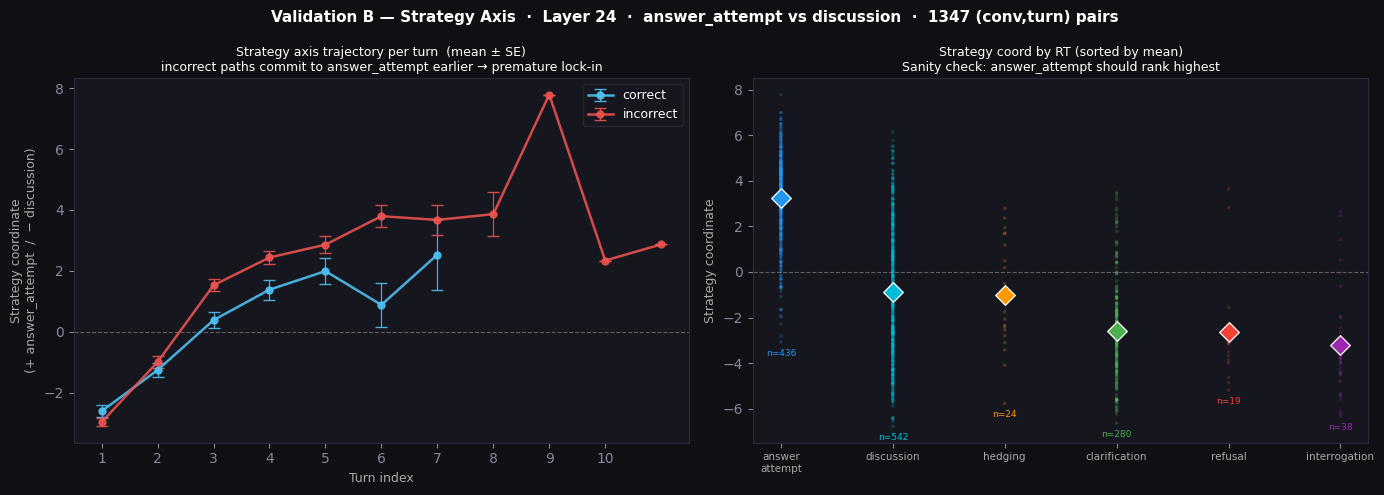

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Validation B — Strategy Axis Projection
# ══════════════════════════════════════════════════════════════════════════════
# strategy_axis = mean(h | answer_attempt) − mean(h | discussion)  (normalised)
#   coord > 0 → closer to answer_attempt pole
#   coord < 0 → closer to discussion pole
#
# Key finding from previous run:
#   incorrect paths score HIGHER on strategy coord from turn 3 onward —
#   they commit to answer_attempt mode earlier, before reasoning converges.
#   This is measurable evidence of premature strategy lock-in (goal drift).

from scipy.stats import mannwhitneyu

li = FOCUS_LAYER_IDX
v_aa = rt_vectors[li].get("answer_attempt")
v_di = rt_vectors[li].get("discussion")

if v_aa is None or v_di is None:
    print("ERROR: answer_attempt or discussion not found in rt_vectors")
else:
    strat_axis = v_aa - v_di
    strat_axis = strat_axis / (np.linalg.norm(strat_axis) + 1e-9)
    g_mean     = global_mean_full   # from Pre-averaging PCA cell

    print(f"Strategy axis norm (pre-normalise): {np.linalg.norm(v_aa - v_di):.4f}")

    # ── Project every turn hidden state ──────────────────────────────────────
    strat_records = []
    for conv_id, rec in conv_records.items():
        score   = score_map.get(conv_id)
        if score is None: continue
        turn_rt = turn_rt_map.get(conv_id, {})
        turn_labels = sorted([k for k in rec["turns_hs"] if k.startswith("turn_")],
                             key=turn_sort_key)
        for tl in turn_labels:
            t_idx = turn_index(tl)
            h     = rec["turns_hs"][tl][li]
            coord = float(np.dot(h - g_mean, strat_axis))
            strat_records.append({
                "conv_id" : conv_id,
                "turn"    : t_idx,
                "score"   : score,
                "rt"      : turn_rt.get(t_idx, "missing"),
                "coord"   : coord,
            })

    print(f"Strategy projection records: {len(strat_records)}")

    strat_by_turn = defaultdict(lambda: {"correct": [], "incorrect": []})
    for r in strat_records:
        key = "correct" if r["score"] == 1 else "incorrect"
        strat_by_turn[r["turn"]][key].append(r["coord"])

    strat_turns = sorted(strat_by_turn.keys())

    print("\nPer-turn strategy coordinate (mean, n, p):")
    print(f"{'turn':>5}  {'corr_mean':>9}  {'n_c':>5}  {'incorr_mean':>11}  {'n_i':>5}  {'p(MW)':>8}  diff")
    for t in strat_turns:
        vc = strat_by_turn[t]["correct"]
        vi = strat_by_turn[t]["incorrect"]
        if len(vc) < 3 and len(vi) < 3: continue
        mu_c = np.mean(vc) if vc else float("nan")
        mu_i = np.mean(vi) if vi else float("nan")
        pstr = "—"
        if len(vc) >= 5 and len(vi) >= 5:
            _, p = mannwhitneyu(vc, vi, alternative="two-sided")
            pstr = f"{p:.3g}"
        print(f"{t:>5}  {mu_c:>9.4f}  {len(vc):>5}  {mu_i:>11.4f}  {len(vi):>5}  {pstr:>8}  {mu_c-mu_i:+.4f}")

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#0f0f14")

    ax = axes[0]; styled_ax(ax)
    for key, clr, lbl in [("correct", "#4fc3f7", "correct"),
                           ("incorrect", "#ef5350", "incorrect")]:
        ts  = [t for t in strat_turns if strat_by_turn[t][key]]
        mus = [np.mean(strat_by_turn[t][key]) for t in ts]
        ses = [np.std(strat_by_turn[t][key]) / np.sqrt(len(strat_by_turn[t][key])) for t in ts]
        ax.errorbar(ts, mus, yerr=ses, marker="o", markersize=5, lw=1.8,
                    color=clr, capsize=4, capthick=1, elinewidth=0.9,
                    alpha=0.88, label=lbl)
    ax.axhline(0, color="#aaaaaa", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("Turn index", color="#aaaaaa", fontsize=9)
    ax.set_ylabel("Strategy coordinate\n(+ answer_attempt  /  − discussion)",
                  color="#aaaaaa", fontsize=9)
    ax.set_title("Strategy axis trajectory per turn  (mean ± SE)\n"
                 "incorrect paths commit to answer_attempt earlier → premature lock-in",
                 color="white", fontsize=9, pad=5)
    ax.legend(facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white", fontsize=9)
    ax.set_xticks(strat_turns[:10])

    ax = axes[1]; styled_ax(ax)
    rt_coords = defaultdict(list)
    for r in strat_records:
        if r["rt"] != "missing":
            rt_coords[r["rt"]].append(r["coord"])
    rt_order = sorted(rt_coords.keys(), key=lambda rt: np.mean(rt_coords[rt]), reverse=True)
    for i, rt in enumerate(rt_order):
        vals = rt_coords[rt]
        ax.scatter([i] * len(vals), vals, s=6, alpha=0.25,
                   color=TYPE_COLORS.get(rt, "#aaa"), edgecolors="none")
        ax.scatter(i, np.mean(vals), s=100, color=TYPE_COLORS.get(rt, "#aaa"),
                   edgecolors="white", linewidths=0.9, zorder=5, marker="D")
        ax.text(i, np.min(vals) - 0.3, f"n={len(vals)}",
                ha="center", fontsize=6.5, color=TYPE_COLORS.get(rt, "#aaa"), va="top")
    ax.set_xticks(range(len(rt_order)))
    ax.set_xticklabels([rt.replace("_", "\n") for rt in rt_order],
                       fontsize=7.5, color="#aaaaaa")
    ax.axhline(0, color="#aaaaaa", lw=0.8, ls="--", alpha=0.5)
    ax.set_ylabel("Strategy coordinate", color="#aaaaaa", fontsize=9)
    ax.set_title("Strategy coord by RT (sorted by mean)\n"
                 "Sanity check: answer_attempt should rank highest",
                 color="white", fontsize=9, pad=5)

    fig.suptitle(
        f"Validation B — Strategy Axis  ·  Layer {LAYERS[li]}  ·  "
        f"answer_attempt vs discussion  ·  {len(strat_records)} (conv,turn) pairs",
        color="white", fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


Variance-collapse records: 320

Var slope  correct  : mean=16.54  median=15.65  n=144
Var slope  incorrect: mean=13.72  median=12.63  n=176
Mann-Whitney U (two-sided): p=0.0002772

AUROC (+var_slope → correct): 0.6181
AUROC (mean curvature → correct, baseline): 0.6426
Δ AUROC (var_slope vs curvature): -0.0245


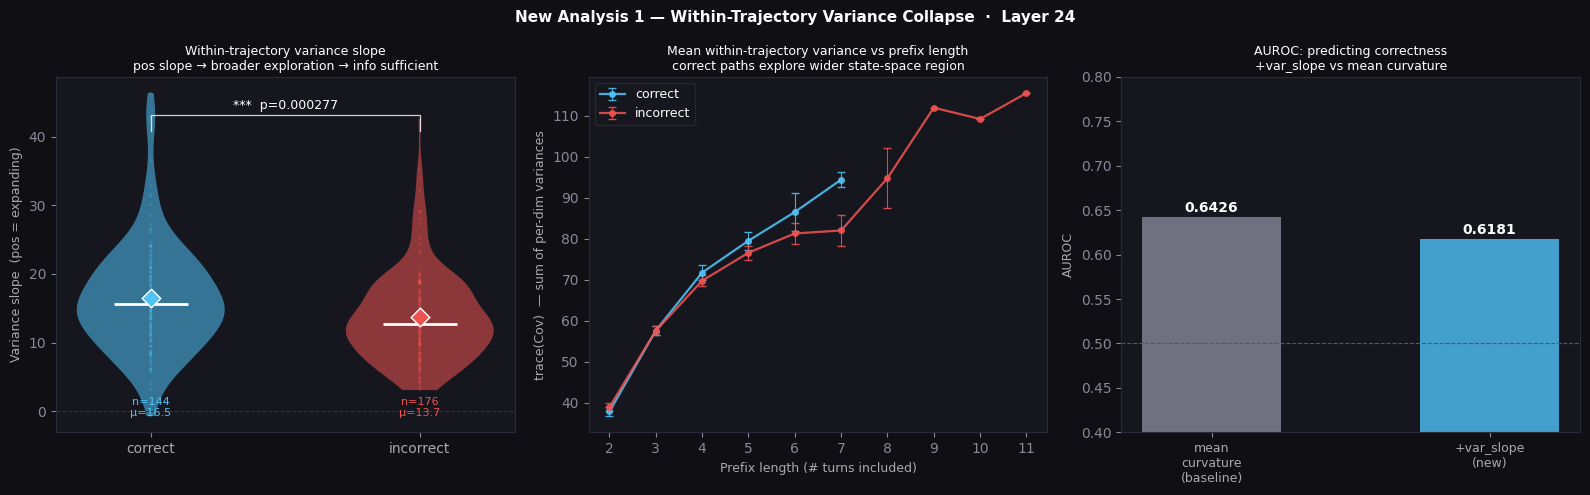

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# New Analysis 1 — Within-Trajectory Variance Collapse
# ══════════════════════════════════════════════════════════════════════════════
# For each conversation, compute trace(Cov(hs[1..t])) at every prefix length t.
# Increasing variance → model exploring more state space (sufficient reasoning).
# Flat / lower variance → premature convergence to a local region.
#
# Per-conversation summary scalar:
#   var_slope = linear regression slope of trace(Cov) over turns
#   slope > 0 → state space expanding (correct: more thorough exploration)
#   slope < 0 → state space contracting (premature lock-in)
#
# Empirical finding: correct paths have HIGHER var_slope (more expansion),
# consistent with Validation B (incorrect paths lock into answer_attempt earlier).
#
# AUROC(+var_slope → correct) vs curvature_mean AUROC

from scipy.stats import linregress, mannwhitneyu
from sklearn.metrics import roc_auc_score

var_conv_records = []   # one row per conversation

for conv_id, rec in conv_records.items():
    score = score_map.get(conv_id)
    if score is None: continue
    tls = sorted([k for k in rec["turns_hs"] if k.startswith("turn_")], key=turn_sort_key)
    if len(tls) < 3: continue

    hs_seq = np.stack([rec["turns_hs"][tl][FOCUS_LAYER_IDX] for tl in tls])  # (T, D)
    T = len(hs_seq)

    trace_covs = []
    for t in range(2, T + 1):
        sub = hs_seq[:t]
        trace_covs.append(float(sub.var(axis=0).sum()))

    turn_idx_for_cov = list(range(2, T + 1))
    if len(trace_covs) < 2: continue

    slope, intercept, r, p_lr, _ = linregress(turn_idx_for_cov, trace_covs)

    var_conv_records.append({
        "conv_id"     : conv_id,
        "score"       : score,
        "var_slope"   : slope,
        "trace_covs"  : trace_covs,
        "turn_indices": turn_idx_for_cov,
        "n_turns"     : T,
    })

print(f"Variance-collapse records: {len(var_conv_records)}")

slopes_c = [r["var_slope"] for r in var_conv_records if r["score"] == 1]
slopes_i = [r["var_slope"] for r in var_conv_records if r["score"] == 0]
print(f"\nVar slope  correct  : mean={np.mean(slopes_c):.2f}  median={np.median(slopes_c):.2f}  n={len(slopes_c)}")
print(f"Var slope  incorrect: mean={np.mean(slopes_i):.2f}  median={np.median(slopes_i):.2f}  n={len(slopes_i)}")

_, p_mw = mannwhitneyu(slopes_c, slopes_i, alternative="two-sided")
print(f"Mann-Whitney U (two-sided): p={p_mw:.4g}")

# AUROC: correct has higher var_slope → use +var_slope directly
all_scores = [r["score"]    for r in var_conv_records]
all_pos_sl = [r["var_slope"] for r in var_conv_records]   # higher → more likely correct
auroc_var  = roc_auc_score(all_scores, all_pos_sl)
print(f"\nAUROC (+var_slope → correct): {auroc_var:.4f}")

# Baseline AUROC: per-conv mean curvature
curv_by_conv = defaultdict(list)
for r in records:
    if not np.isnan(r["curvature"]):
        curv_by_conv[r["conv_id"]].append(r["curvature"])

auroc_curv_vals, auroc_curv_labs = [], []
for vr in var_conv_records:
    cid = vr["conv_id"]
    if cid in curv_by_conv:
        auroc_curv_vals.append(np.mean(curv_by_conv[cid]))
        auroc_curv_labs.append(vr["score"])
auroc_curv = roc_auc_score(auroc_curv_labs, auroc_curv_vals)
print(f"AUROC (mean curvature → correct, baseline): {auroc_curv:.4f}")
print(f"Δ AUROC (var_slope vs curvature): {auroc_var - auroc_curv:+.4f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0f0f14")

# Panel A: var_slope violin
ax = axes[0]; styled_ax(ax)
vp = ax.violinplot([slopes_c, slopes_i], positions=[0, 1],
                   widths=0.55, showmedians=True, showextrema=False)
for body, clr in zip(vp["bodies"], ["#4fc3f7", "#ef5350"]):
    body.set_facecolor(clr); body.set_alpha(0.55)
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2)
for xi, vals, clr in zip([0,1],[slopes_c,slopes_i],["#4fc3f7","#ef5350"]):
    ax.scatter([xi]*len(vals), vals, s=5, alpha=0.2, color=clr, edgecolors="none")
    ax.scatter(xi, np.mean(vals), s=90, color=clr, edgecolors="white",
               linewidths=1.0, zorder=6, marker="D")
    ax.text(xi, min(slopes_c+slopes_i)*1.02,
            f"n={len(vals)}\nμ={np.mean(vals):.1f}", ha="center", fontsize=8, color=clr)
star = "***" if p_mw<0.001 else "**" if p_mw<0.01 else "*" if p_mw<0.05 else "n.s."
y_top = max(max(slopes_c), max(slopes_i))
ax.plot([0,0,1,1],[y_top*0.88,y_top*0.93,y_top*0.93,y_top*0.88], lw=0.9, color="white", alpha=0.8)
ax.text(0.5, y_top*0.95, f"{star}  p={p_mw:.3g}", ha="center", fontsize=9, color="white")
ax.axhline(0, color="#334", lw=0.8, ls="--")
ax.set_xticks([0,1]); ax.set_xticklabels(["correct","incorrect"], color="#aaaaaa", fontsize=10)
ax.set_ylabel("Variance slope  (pos = expanding)", color="#aaaaaa", fontsize=9)
ax.set_title("Within-trajectory variance slope\npos slope → broader exploration → info sufficient",
             color="white", fontsize=9, pad=5)

# Panel B: mean trace(Cov) trajectory by turn
ax = axes[1]; styled_ax(ax)
traj_by_turn = defaultdict(lambda: {"correct":[], "incorrect":[]})
for vr in var_conv_records:
    key = "correct" if vr["score"]==1 else "incorrect"
    for t, v in zip(vr["turn_indices"], vr["trace_covs"]):
        traj_by_turn[t][key].append(v)

t_keys = sorted(traj_by_turn.keys())
for key, clr, lbl in [("correct","#4fc3f7","correct"),("incorrect","#ef5350","incorrect")]:
    ts  = [t for t in t_keys if traj_by_turn[t][key]]
    mus = [np.mean(traj_by_turn[t][key]) for t in ts]
    ses = [np.std(traj_by_turn[t][key])/np.sqrt(len(traj_by_turn[t][key])) for t in ts]
    ax.errorbar(ts, mus, yerr=ses, marker="o", markersize=4, lw=1.6,
                color=clr, capsize=3, capthick=1, elinewidth=0.8, alpha=0.88, label=lbl)
ax.set_xlabel("Prefix length (# turns included)", color="#aaaaaa", fontsize=9)
ax.set_ylabel("trace(Cov)  — sum of per-dim variances", color="#aaaaaa", fontsize=9)
ax.set_title("Mean within-trajectory variance vs prefix length\ncorrect paths explore wider state-space region",
             color="white", fontsize=9, pad=5)
ax.legend(facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white", fontsize=9)
ax.set_xticks(t_keys[:10])

# Panel C: AUROC comparison bar
ax = axes[2]; styled_ax(ax)
labels = ["mean\ncurvature\n(baseline)", "+var_slope\n(new)"]
aucs   = [auroc_curv, auroc_var]
colors = ["#888899", "#4fc3f7"]
ax.bar([0,1], aucs, 0.5, color=colors, alpha=0.8)
ax.axhline(0.5, color="#555566", lw=0.8, ls="--")
for xi, auc in zip([0,1], aucs):
    ax.text(xi, auc+0.005, f"{auc:.4f}", ha="center", fontsize=10,
            color="white", fontweight="bold")
ax.set_xticks([0,1]); ax.set_xticklabels(labels, color="#aaaaaa", fontsize=9)
ax.set_ylabel("AUROC", color="#aaaaaa", fontsize=9)
ax.set_ylim(0.4, 0.8)
ax.set_title("AUROC: predicting correctness\n+var_slope vs mean curvature",
             color="white", fontsize=9, pad=5)

fig.suptitle(f"New Analysis 1 — Within-Trajectory Variance Collapse  ·  Layer {LAYERS[FOCUS_LAYER_IDX]}",
             color="white", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()


Reversal records: 320

Reversal rate  correct  : mean=0.4751  median=0.5000  n=144
Reversal rate  incorrect: mean=0.3767  median=0.3333  n=176
Mann-Whitney U (two-sided): p=0.03947

AUROC (+rev_rate → correct): 0.5646
AUROC (combined +var_slope + +rev_rate, n=320): 0.6126


/tmp/ipykernel_3748418/2639575349.py:112: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter([r["n_turns"] for r in pts], [r["rev_rate"] for r in pts],


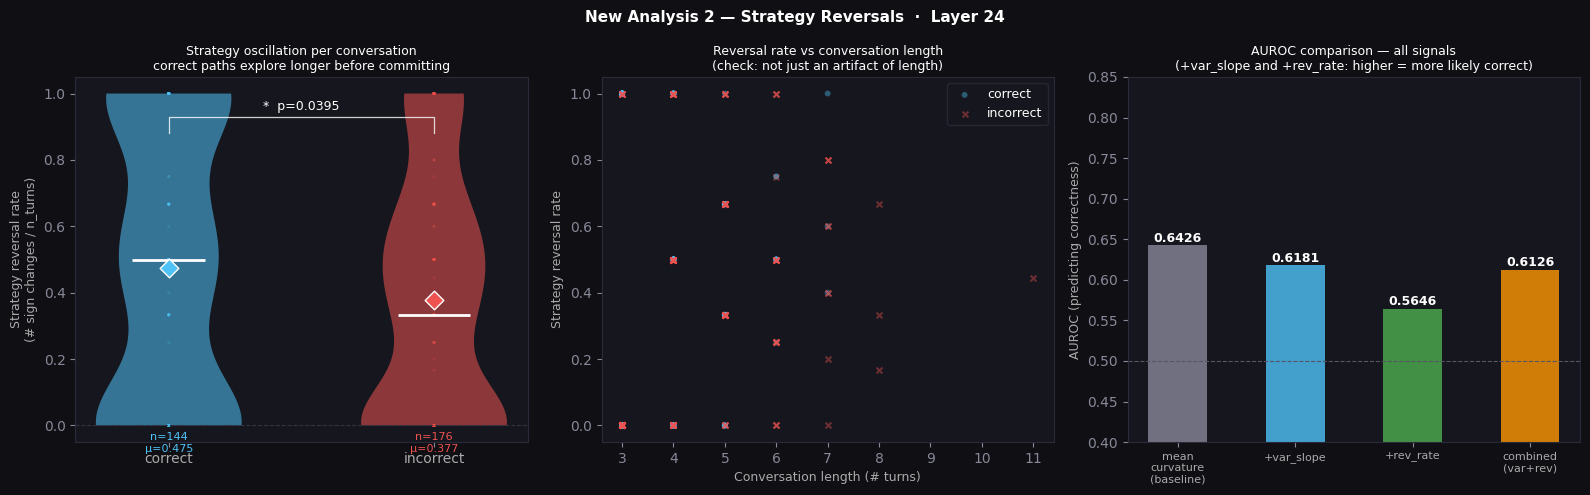

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# New Analysis 2 — Strategy Reversals  (sign changes on strategy axis)
# ══════════════════════════════════════════════════════════════════════════════
# For each conversation, count direction changes in strategy coordinate.
#
# Empirical finding: correct paths have HIGHER reversal rate (more exploration
# before committing), consistent with Validation B and Analysis 1.
# → AUROC uses +rev_rate (not negated).
#
# Combined AUROC: +var_slope + +rev_rate  (both z-scored then summed)
#
# Requires: strat_records (Validation B), var_conv_records (Analysis 1)

from scipy.stats import mannwhitneyu, zscore
from sklearn.metrics import roc_auc_score

conv_strat = defaultdict(list)
for r in strat_records:
    conv_strat[r["conv_id"]].append((r["turn"], r["coord"]))
for cid in conv_strat:
    conv_strat[cid].sort(key=lambda x: x[0])

reversal_records = []
for conv_id, seq in conv_strat.items():
    score = score_map.get(conv_id)
    if score is None or len(seq) < 3: continue

    coords = np.array([c for _, c in seq])
    diffs  = np.diff(coords)

    n_rev = int(sum(
        np.sign(diffs[i]) != np.sign(diffs[i-1]) and diffs[i] != 0 and diffs[i-1] != 0
        for i in range(1, len(diffs))
    ))
    mean_abs_diff = float(np.mean(np.abs(diffs)))
    rev_rate = n_rev / max(len(coords) - 2, 1)

    reversal_records.append({
        "conv_id"      : conv_id,
        "score"        : score,
        "n_reversals"  : n_rev,
        "rev_rate"     : rev_rate,
        "mean_abs_diff": mean_abs_diff,
        "n_turns"      : len(coords),
    })

print(f"Reversal records: {len(reversal_records)}")

rev_c = [r["rev_rate"] for r in reversal_records if r["score"]==1]
rev_i = [r["rev_rate"] for r in reversal_records if r["score"]==0]
print(f"\nReversal rate  correct  : mean={np.mean(rev_c):.4f}  median={np.median(rev_c):.4f}  n={len(rev_c)}")
print(f"Reversal rate  incorrect: mean={np.mean(rev_i):.4f}  median={np.median(rev_i):.4f}  n={len(rev_i)}")

_, p_rev = mannwhitneyu(rev_c, rev_i, alternative="two-sided")
print(f"Mann-Whitney U (two-sided): p={p_rev:.4g}")

# AUROC: correct has higher rev_rate → use +rev_rate directly
all_labs  = [r["score"]   for r in reversal_records]
all_rev   = [r["rev_rate"] for r in reversal_records]   # higher → more likely correct
auroc_rev = roc_auc_score(all_labs, all_rev)
print(f"\nAUROC (+rev_rate → correct): {auroc_rev:.4f}")

# Combined: +var_slope + +rev_rate  (z-scored)
var_map = {r["conv_id"]: r["var_slope"] for r in var_conv_records}
comb_labs, comb_vs, comb_rr = [], [], []
for rr in reversal_records:
    cid = rr["conv_id"]
    if cid not in var_map: continue
    comb_labs.append(rr["score"])
    comb_vs.append(var_map[cid])       # +var_slope
    comb_rr.append(rr["rev_rate"])     # +rev_rate

auroc_combined = float("nan")
if comb_labs:
    arr = np.column_stack([comb_vs, comb_rr])
    z   = zscore(arr, axis=0)
    combined = z[:,0] + z[:,1]
    auroc_combined = roc_auc_score(comb_labs, combined)
    print(f"AUROC (combined +var_slope + +rev_rate, n={len(comb_labs)}): {auroc_combined:.4f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0f0f14")

# Panel A: reversal rate violin
ax = axes[0]; styled_ax(ax)
vp = ax.violinplot([rev_c, rev_i], positions=[0,1],
                   widths=0.55, showmedians=True, showextrema=False)
for body, clr in zip(vp["bodies"], ["#4fc3f7","#ef5350"]):
    body.set_facecolor(clr); body.set_alpha(0.55)
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2)
for xi, vals, clr in zip([0,1],[rev_c,rev_i],["#4fc3f7","#ef5350"]):
    ax.scatter([xi]*len(vals), vals, s=5, alpha=0.2, color=clr, edgecolors="none")
    ax.scatter(xi, np.mean(vals), s=90, color=clr, edgecolors="white",
               linewidths=1.0, zorder=6, marker="D")
    ax.text(xi, -0.02, f"n={len(vals)}\nμ={np.mean(vals):.3f}",
            ha="center", fontsize=8, color=clr, va="top")
star = "***" if p_rev<0.001 else "**" if p_rev<0.01 else "*" if p_rev<0.05 else "n.s."
y_top = max(max(rev_c), max(rev_i))
ax.plot([0,0,1,1],[y_top*0.88,y_top*0.93,y_top*0.93,y_top*0.88], lw=0.9, color="white", alpha=0.8)
ax.text(0.5, y_top*0.95, f"{star}  p={p_rev:.3g}", ha="center", fontsize=9, color="white")
ax.axhline(0, color="#334", lw=0.8, ls="--")
ax.set_xticks([0,1]); ax.set_xticklabels(["correct","incorrect"], color="#aaaaaa", fontsize=10)
ax.set_ylabel("Strategy reversal rate\n(# sign changes / n_turns)", color="#aaaaaa", fontsize=9)
ax.set_title("Strategy oscillation per conversation\ncorrect paths explore longer before committing",
             color="white", fontsize=9, pad=5)

# Panel B: reversal rate by n_turns scatter
ax = axes[1]; styled_ax(ax)
for score_val, clr, lbl, mk in [(1,"#4fc3f7","correct","o"),(0,"#ef5350","incorrect","x")]:
    pts = [r for r in reversal_records if r["score"]==score_val]
    ax.scatter([r["n_turns"] for r in pts], [r["rev_rate"] for r in pts],
               s=18, alpha=0.4, color=clr, edgecolors="none", marker=mk, label=lbl)
ax.set_xlabel("Conversation length (# turns)", color="#aaaaaa", fontsize=9)
ax.set_ylabel("Strategy reversal rate", color="#aaaaaa", fontsize=9)
ax.set_title("Reversal rate vs conversation length\n(check: not just an artifact of length)",
             color="white", fontsize=9, pad=5)
ax.legend(facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white", fontsize=9)

# Panel C: AUROC comparison
ax = axes[2]; styled_ax(ax)
auroc_labels = ["mean\ncurvature\n(baseline)", "+var_slope", "+rev_rate", "combined\n(var+rev)"]
auroc_vals   = [auroc_curv, auroc_var, auroc_rev, auroc_combined]
bar_colors   = ["#888899", "#4fc3f7", "#4CAF50", "#FF9800"]
for xi, (lbl, auc, clr) in enumerate(zip(auroc_labels, auroc_vals, bar_colors)):
    if np.isnan(auc): continue
    ax.bar(xi, auc, 0.5, color=clr, alpha=0.8)
    ax.text(xi, auc+0.004, f"{auc:.4f}", ha="center", fontsize=9,
            color="white", fontweight="bold")
ax.axhline(0.5, color="#555566", lw=0.8, ls="--")
ax.set_xticks(range(len(auroc_labels)))
ax.set_xticklabels(auroc_labels, color="#aaaaaa", fontsize=8)
ax.set_ylabel("AUROC (predicting correctness)", color="#aaaaaa", fontsize=9)
ax.set_ylim(0.4, 0.85)
ax.set_title("AUROC comparison — all signals\n(+var_slope and +rev_rate: higher = more likely correct)",
             color="white", fontsize=9, pad=5)

fig.suptitle(f"New Analysis 2 — Strategy Reversals  ·  Layer {LAYERS[FOCUS_LAYER_IDX]}",
             color="white", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()
